# Assignment: Trees, Bagging, Boosting and PCA / Feature Selection
**Dataset:** Dry Bean Dataset (13,611 samples, 16 numerical features, 7 bean varieties)
**Protocol:** 80% train / 20% test, `random_state=42`, `stratify=y`. All random components use `random_state=42`, so the notebook is fully reproducible.

> **Note on the data file.** The assignment mentions an Excel file; the provided file is the same dataset as CSV. The loader accepts both `.csv` and `.xlsx`.
> **Note on cleaning vs. splitting.** Duplicates are removed *before* the split so that identical rows can never appear in both train and test.


In [1]:
#وما توفيقي الا بالله 

%pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              GradientBoostingClassifier)
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

## 0. Load the data

In [3]:
def find_dataset():
    """Look for the Dry Bean file (csv or xlsx) in common locations."""
    folders = [".", "data", "/mnt/user-data/uploads"]
    patterns = ["*Dry*Bean*.csv", "*Dry*Bean*.xlsx", "*dry*bean*.csv", "*dry*bean*.xlsx"]
    for folder in folders:
        for pat in patterns:
            hits = sorted(glob.glob(os.path.join(folder, pat)))
            if hits:
                return hits[0]
    raise FileNotFoundError("Put the Dry Bean file (csv or xlsx) next to this notebook.")

path = find_dataset()
print("Loading:", os.path.basename(path))
df = pd.read_excel(path) if path.endswith(".xlsx") else pd.read_csv(path)
print("Shape:", df.shape)
df.head()

Loading: Dry_Bean_Dataset (1).csv
Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
target = "Class"
feature_cols = [c for c in df.columns if c != target]
print(f"{len(feature_cols)} features, target = '{target}'")
print("\nClass distribution:")
print(df[target].value_counts().to_string())
df.describe().T.round(3)

16 features, target = 'Class'

Class distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522


,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.285,29324.096,20420.000,36328.000,44652.000,61332.000,254616.000
Perimeter,13611.0,855.283,214.290,524.736,703.524,794.941,977.213,1985.370
MajorAxisLength,13611.0,320.142,85.694,183.601,253.304,296.883,376.495,738.860
MinorAxisLength,13611.0,202.271,44.970,122.513,175.848,192.432,217.032,460.198
AspectRation,13611.0,1.583,0.247,1.025,1.432,1.551,1.707,2.430
Eccentricity,13611.0,0.751,0.092,0.219,0.716,0.764,0.810,0.911
ConvexArea,13611.0,53768.200,29774.916,20684.000,36714.500,45178.000,62294.000,263261.000
EquivDiameter,13611.0,253.064,59.177,161.244,215.068,238.438,279.446,569.374
Extent,13611.0,0.750,0.049,0.555,0.719,0.760,0.787,0.866
Solidity,13611.0,0.987,0.005,0.919,0.986,0.988,0.990,0.995


## 1. Decision Tree

### Step 1 - Exploratory analysis

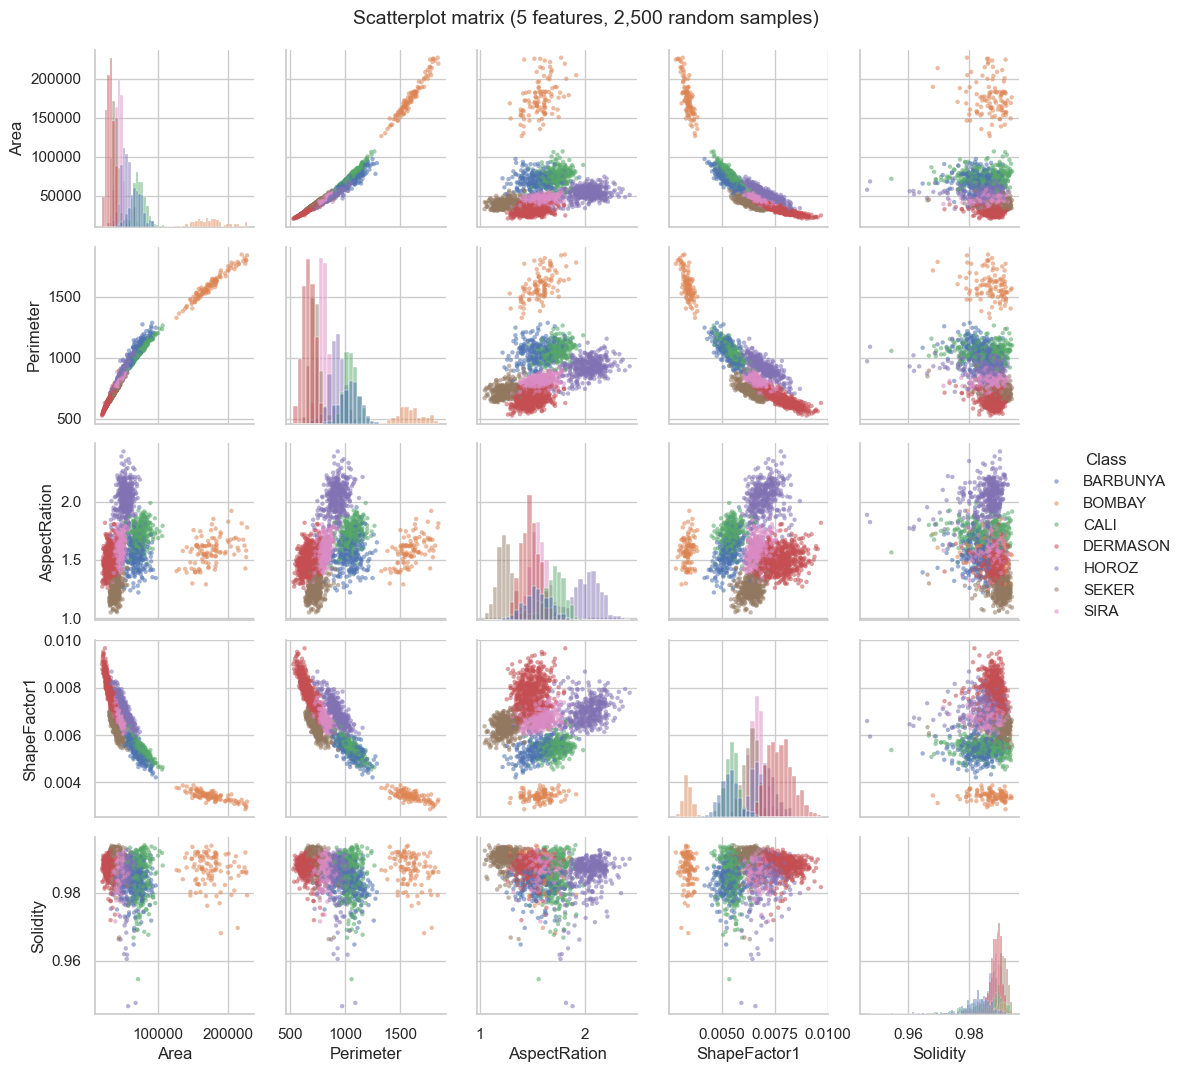

In [5]:
# (1a) Scatterplot matrix of 5 representative features.
# Chosen to mix size (Area, Perimeter), shape (AspectRation, ShapeFactor1) and Solidity.
five = ["Area", "Perimeter", "AspectRation", "ShapeFactor1", "Solidity"]
sample = df.sample(n=2500, random_state=RANDOM_STATE)   # subsample only for plotting speed
order = sorted(df[target].unique())
g = sns.pairplot(sample, vars=five, hue=target, hue_order=order, diag_kind="hist",
                 plot_kws=dict(s=10, alpha=0.55, linewidth=0), height=2.1, corner=False)
g.figure.suptitle("Scatterplot matrix (5 features, 2,500 random samples)", y=1.02, fontsize=14)
plt.show()

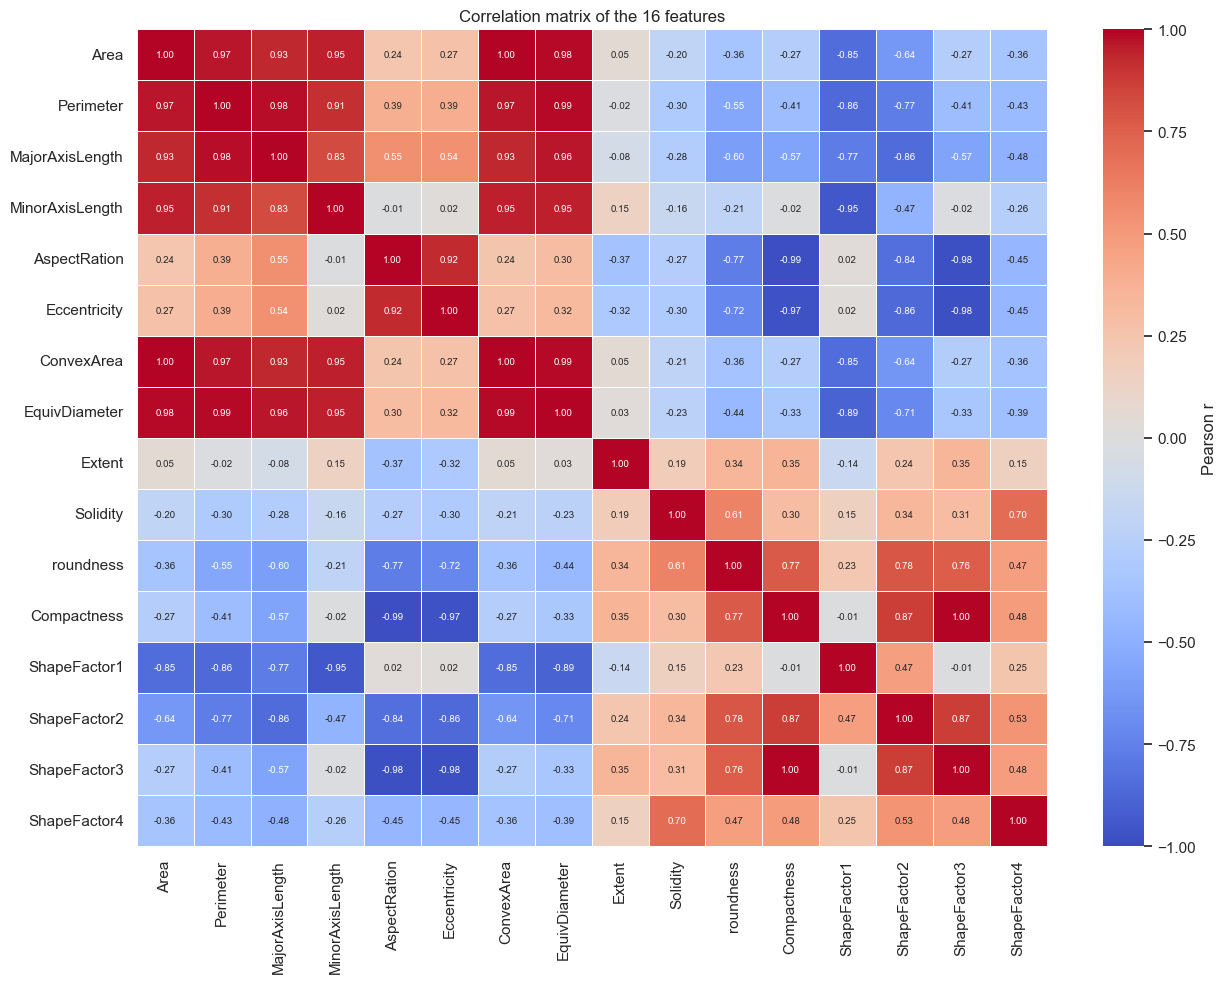

In [6]:
# (1b) Heatmap of the full feature correlation matrix
corr = df[feature_cols].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            annot_kws={"size": 7}, linewidths=0.4, cbar_kws={"label": "Pearson r"})
plt.title("Correlation matrix of the 16 features")
plt.tight_layout(); plt.show()

In [7]:
# Quantify the two observations the plots suggest
# (i) redundancy: pairs with |r| >= 0.95
pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
             .stack().rename("r").reset_index())
pairs.columns = ["feature_1", "feature_2", "r"]
high = pairs[pairs["r"].abs() >= 0.95].sort_values("r", key=abs, ascending=False)
print("Highly correlated pairs (|r| >= 0.95):")
print(high.round(3).to_string(index=False))

# (ii) separability: ANOVA F-statistic of every feature against the class label
F, p = f_classif(df[feature_cols], df[target])
sep = pd.DataFrame({"F_statistic": F, "p_value": p}, index=feature_cols).sort_values("F_statistic", ascending=False)
print("\nClass separability per feature (ANOVA F, larger = better separated):")
print(sep.round(4).to_string())

Highly correlated pairs (|r| >= 0.95):
      feature_1       feature_2      r
           Area      ConvexArea  1.000
    Compactness    ShapeFactor3  0.999
      Perimeter   EquivDiameter  0.991
   AspectRation     Compactness -0.988
     ConvexArea   EquivDiameter  0.985
           Area   EquivDiameter  0.985
   Eccentricity    ShapeFactor3 -0.981
   AspectRation    ShapeFactor3 -0.979
      Perimeter MajorAxisLength  0.977
   Eccentricity     Compactness -0.970
      Perimeter      ConvexArea  0.968
           Area       Perimeter  0.967
MajorAxisLength   EquivDiameter  0.962
           Area MinorAxisLength  0.952
MinorAxisLength      ConvexArea  0.951

Class separability per feature (ANOVA F, larger = better separated):
                 F_statistic  p_value
Area              29017.5105      0.0
ConvexArea        28961.7912      0.0
EquivDiameter     25444.5478      0.0
Perimeter         24283.6637      0.0
MinorAxisLength   22442.3864      0.0
MajorAxisLength   21622.2379      0.0
S

#### Summary of the exploratory analysis

**Most separable features.** The ANOVA F-statistics and the scatter matrix agree:
- **Size features** (`Area`, `ConvexArea`, `EquivDiameter`, `Perimeter`, `MinorAxisLength`, `MajorAxisLength`) separate the classes best (F between 21,600 and 29,000). In particular **BOMBAY** is almost isolated: its beans are far larger than all others (Area > ~100,000 in the plot).
- **Shape features** come next: `ShapeFactor1`, `ShapeFactor2`, `AspectRation`, `Compactness` (F ~ 10,000-12,300). `AspectRation` separates HOROZ (elongated) from SEKER (round), and `ShapeFactor1` separates DERMASON from SEKER and from the large classes.
- **Weakest features:** `Extent`, `Solidity` and `ShapeFactor4` (F < 1,300): the classes overlap almost completely on them.
- Even so, no single feature separates everything: **SIRA, DERMASON, SEKER (small beans) and BARBUNYA / CALI (medium beans)** overlap heavily in the 2D plots, which anticipates the confusions seen later.

**Redundant features (|r| >= 0.95, 15 pairs).**
- *Size group:* `Area` and `ConvexArea` are almost identical (r = 1.000); `EquivDiameter`, `Perimeter`, `MajorAxisLength` and `MinorAxisLength` are all >= 0.95 correlated with `Area`/`ConvexArea` (e.g. Area-EquivDiameter 0.985, Area-Perimeter 0.967).
- *Shape group:* `Compactness` and `ShapeFactor3` (r = 0.999), `AspectRation` and `Compactness` (r = -0.988), `Eccentricity` and `ShapeFactor3` (r = -0.981).
- In practice the 16 features carry far fewer than 16 independent pieces of information (one "size" direction and one "elongation" direction dominate). This is why PCA in Section 4 can compress the data so strongly. Tree-based models are not hurt by correlated inputs, but the importance of correlated features gets shared between them, which matters when interpreting feature importances.


### Step 2 - Data cleaning, encoding and train/test split

In [8]:
# (2) Data quality checks
print("Missing values per column (total):", int(df.isna().sum().sum()))
print("\nData types:")
print(df.dtypes.value_counts().to_string())
non_numeric = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
print("\nNon-numeric feature columns:", non_numeric if non_numeric else "none -> all 16 features are numerical")

n_before = len(df)
n_dup = int(df.duplicated().sum())
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"\nDuplicate rows found and removed: {n_dup}")
print(f"Samples before cleaning: {n_before:,}   after cleaning: {len(df_clean):,}")

# Encode the categorical target
le = LabelEncoder()
y = le.fit_transform(df_clean[target])
class_names = list(le.classes_)
print("\nLabel encoding:", {c: int(i) for i, c in enumerate(class_names)})
X = df_clean[feature_cols].copy()

# Split: 80/20, random_state=42, stratified (cleaning is done BEFORE the split to avoid duplicates leaking across sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"\nTrain: {X_train.shape}   Test: {X_test.shape}")

Missing values per column (total): 0

Data types:
float64    14
int64       2
object      1

Non-numeric feature columns: none -> all 16 features are numerical

Duplicate rows found and removed: 68
Samples before cleaning: 13,611   after cleaning: 13,543

Label encoding: {'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}

Train: (10834, 16)   Test: (2709, 16)


In [9]:
# ---------- shared helpers & result stores ----------
fit_times = {}      # seconds, final version of each model
final_models = {}   # fitted model objects for the 6 required models
final_preds = {}    # test-set predictions of those models

def weighted_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {"Precision": p, "Recall": r, "Accuracy": accuracy_score(y_true, y_pred), "F1-score": f1}

def show_cm(y_true, y_pred, title, ax=None):
    ax_given = ax is not None
    if not ax_given:
        fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=class_names,
                                            xticks_rotation=45, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title); ax.grid(False)
    if not ax_given:
        plt.tight_layout(); plt.show()

def top_confusions(y_true, y_pred, k=5):
    cm = confusion_matrix(y_true, y_pred)
    rows = [(class_names[i], class_names[j], cm[i, j]) for i in range(len(cm)) for j in range(len(cm)) if i != j and cm[i, j] > 0]
    out = pd.DataFrame(rows, columns=["True class", "Predicted as", "Count"]).sort_values("Count", ascending=False).head(k)
    return out.reset_index(drop=True)

def per_class_recall(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return pd.Series(cm.diagonal() / cm.sum(axis=1), index=class_names, name="Recall").sort_values()

### Step 3 - Default Decision Tree

Train accuracy: 1.0000
Test  accuracy: 0.8966
Tree depth: 27   leaves: 694


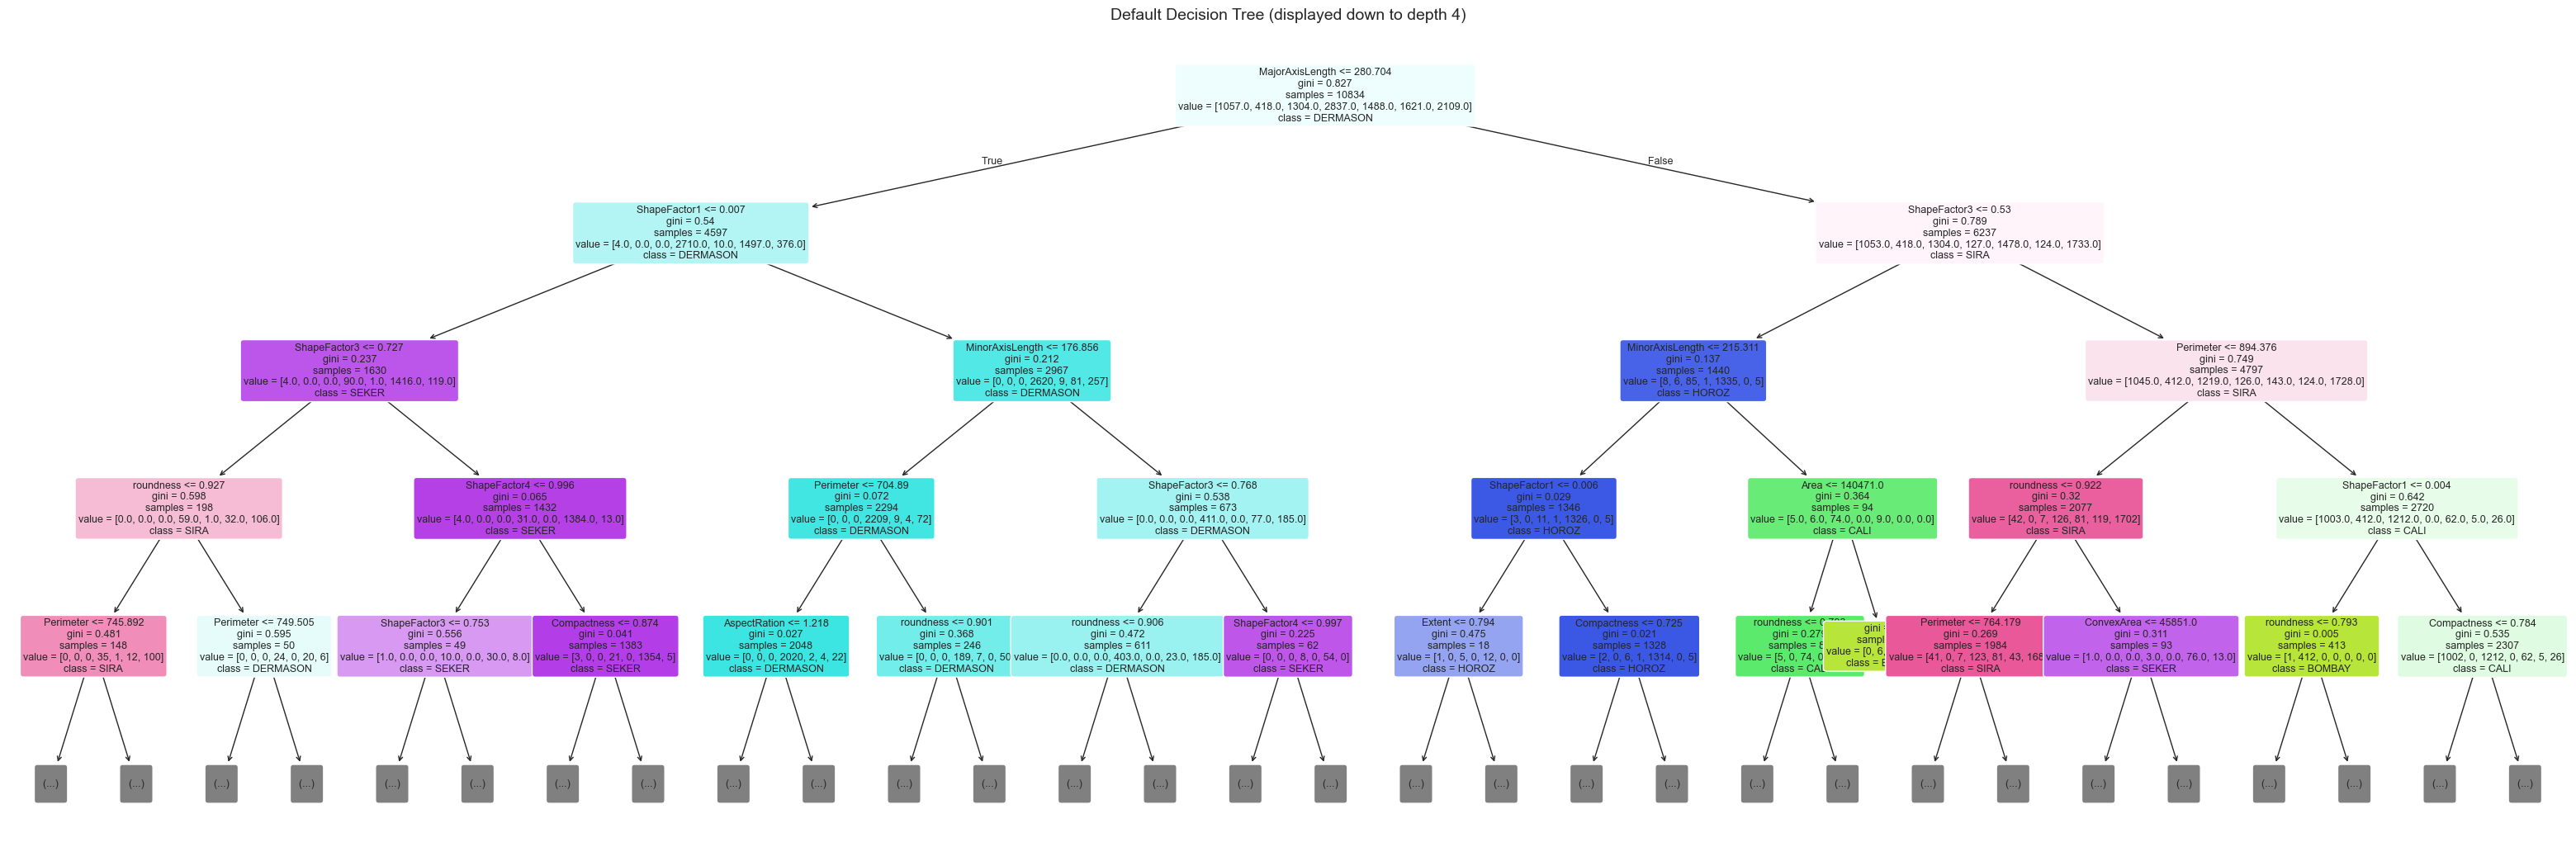

In [10]:
# (3) Default Decision Tree
t0 = time.perf_counter()
dt = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
fit_times["Decision Tree"] = time.perf_counter() - t0

pred_dt = dt.predict(X_test)
print(f"Train accuracy: {accuracy_score(y_train, dt.predict(X_train)):.4f}")
print(f"Test  accuracy: {accuracy_score(y_test, pred_dt):.4f}")
print(f"Tree depth: {dt.get_depth()}   leaves: {dt.get_n_leaves()}")

plt.figure(figsize=(40, 13))
plot_tree(dt, max_depth=4, feature_names=feature_cols, class_names=class_names,
          filled=True, rounded=True, fontsize=9, precision=3, impurity=True)
plt.title("Default Decision Tree (displayed down to depth 4)", fontsize=14)
plt.show()

In [11]:
# Interpretation of the top-3 splitting nodes (root + its two children)
t = dt.tree_
def composition(node, thr=0.05):
    v = t.value[node][0]; v = v / v.sum()
    return ", ".join(f"{class_names[i]} {v[i]:.0%}" for i in np.argsort(-v) if v[i] >= thr)

top_nodes = [("Node 1 (root)", 0), ("Node 2 (left child of root)", t.children_left[0]),
             ("Node 3 (right child of root)", t.children_right[0])]
for label, n in top_nodes:
    f, thr = feature_cols[t.feature[n]], t.threshold[n]
    l, r = t.children_left[n], t.children_right[n]
    print(f"{label}:  {f} <= {thr:.4f}   (samples = {t.n_node_samples[n]:,})")
    print(f"    YES (<= {thr:.4g}) -> {composition(l)}")
    print(f"    NO  (>  {thr:.4g}) -> {composition(r)}\n")

Node 1 (root):  MajorAxisLength <= 280.7042   (samples = 10,834)
    YES (<= 280.7) -> DERMASON 59%, SEKER 33%, SIRA 8%
    NO  (>  280.7) -> SIRA 28%, HOROZ 24%, CALI 21%, BARBUNYA 17%, BOMBAY 7%

Node 2 (left child of root):  ShapeFactor1 <= 0.0068   (samples = 4,597)
    YES (<= 0.006821) -> SEKER 87%, SIRA 7%, DERMASON 6%
    NO  (>  0.006821) -> DERMASON 88%, SIRA 9%

Node 3 (right child of root):  ShapeFactor3 <= 0.5304   (samples = 6,237)
    YES (<= 0.5304) -> HOROZ 93%, CALI 6%
    NO  (>  0.5304) -> SIRA 36%, CALI 25%, BARBUNYA 22%, BOMBAY 9%



**Interpretation of the top 3 splits**

1. **Root: `MajorAxisLength <= 280.7`.** Separates the *small* beans (left: mostly DERMASON 59%, SEKER 33%, some SIRA) from the *large* beans (right: SIRA, HOROZ, CALI, BARBUNYA, BOMBAY). It is a size split.
2. **Left child: `ShapeFactor1 <= 0.0068`.** Inside the small beans, it separates **SEKER** (87% pure when `ShapeFactor1` is low) from **DERMASON** (88% pure when it is high).
3. **Right child: `Compactness <= 0.7283`.** Inside the large beans it isolates **HOROZ** (93% pure, the elongated, low-compactness beans) from SIRA / CALI / BARBUNYA / BOMBAY, which are separated by deeper splits (e.g. BOMBAY through a `ShapeFactor1` split at depth 4).


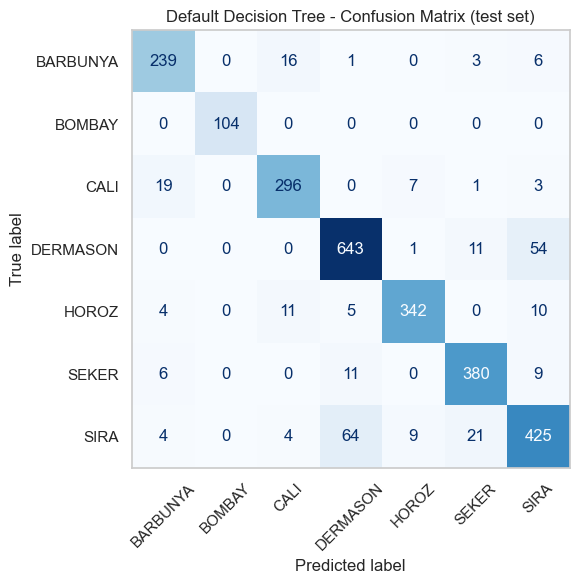

Most frequent confusions:
True class Predicted as  Count
      SIRA     DERMASON     64
  DERMASON         SIRA     54
      SIRA        SEKER     21
      CALI     BARBUNYA     19
  BARBUNYA         CALI     16

Per-class recall (worst first):
SIRA        0.8065
BARBUNYA    0.9019
DERMASON    0.9069
CALI        0.9080
HOROZ       0.9194
SEKER       0.9360
BOMBAY      1.0000


In [12]:
show_cm(y_test, pred_dt, "Default Decision Tree - Confusion Matrix (test set)")
print("Most frequent confusions:")
print(top_confusions(y_test, pred_dt).to_string(index=False))
print("\nPer-class recall (worst first):")
print(per_class_recall(y_test, pred_dt).round(4).to_string())

**Generalisation and errors of the default tree.** Train accuracy is 100% but test accuracy is 89.55%: the unrestricted tree (depth 27, 701 leaves) memorises the training set, a classic high-variance behaviour.

**Most misclassified varieties:** **SIRA** (recall 0.81) is the hardest class and is confused mainly with **DERMASON** (61 + 57 errors in the two directions) and **SEKER**; **BARBUNYA <-> CALI** (18 errors each way) is the second problematic pair. **BOMBAY** is classified perfectly (recall 1.00) because of its very distinctive size.


### Step 4 - Improving the Decision Tree

In [13]:
# (4) Improving the Decision Tree
rows = []
def add_variant(name, model, group):
    model.fit(X_train, y_train)
    rows.append({"Group": group, "Variant": name,
                 "Train acc": accuracy_score(y_train, model.predict(X_train)),
                 "Test acc": accuracy_score(y_test, model.predict(X_test)),
                 "Depth": model.get_depth(), "Leaves": model.get_n_leaves()})
    return model

# Approach 1: splitting criterion (otherwise default settings)
for crit in ["gini", "entropy"]:
    add_variant(f"criterion={crit} (unlimited depth)", DecisionTreeClassifier(criterion=crit, random_state=RANDOM_STATE), "1. Criterion")

# Approach 2: max_depth, shallow -> deep, for both criteria
depth_values = [2, 3, 4, 5, 6, 8, 10, 15]
for crit in ["gini", "entropy"]:
    for d in depth_values:
        add_variant(f"{crit}, max_depth={d}", DecisionTreeClassifier(criterion=crit, max_depth=d, random_state=RANDOM_STATE), "2. max_depth")
depth_df = pd.DataFrame(rows)
print("Approach 1 and 2 done.")

Approach 1 and 2 done.


Best ccp_alpha (by test accuracy): 0.000170  -> test acc 0.9125, depth 16, leaves 276


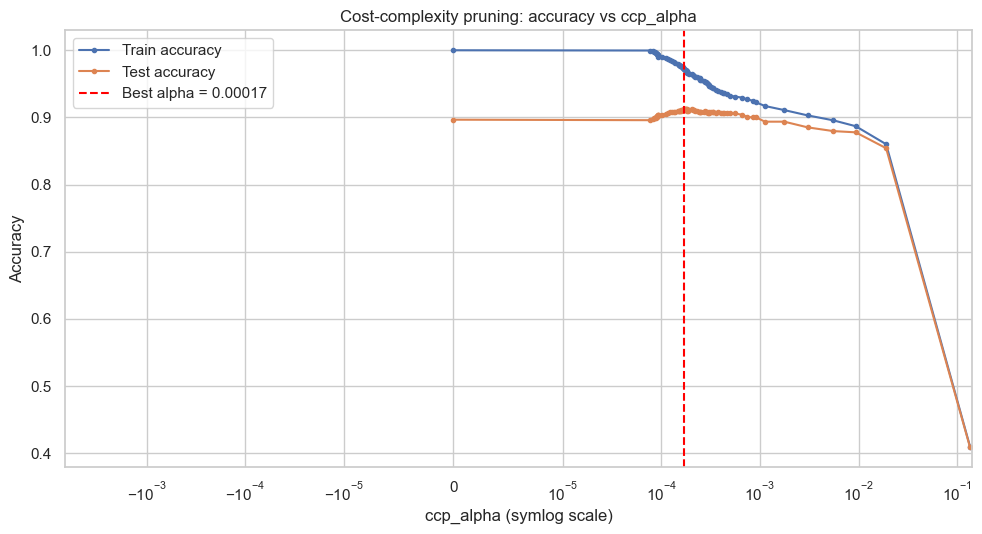

CV-selected alpha (train data only): 0.000427 -> test acc 0.9066


In [14]:
# Approach 3: cost-complexity pruning (tune ccp_alpha)
path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train, y_train)
alphas = np.unique(path.ccp_alphas[:-1])             # last alpha prunes the whole tree to the root
if len(alphas) > 80:                                  # keep ~80 candidates spread over the path
    alphas = alphas[np.unique(np.linspace(0, len(alphas) - 1, 80).astype(int))]

ccp_rows, ccp_models = [], {}
for a in alphas:
    m = DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE).fit(X_train, y_train)
    ccp_models[a] = m
    ccp_rows.append({"alpha": a, "train": accuracy_score(y_train, m.predict(X_train)),
                     "test": accuracy_score(y_test, m.predict(X_test)),
                     "depth": m.get_depth(), "leaves": m.get_n_leaves()})
ccp_df = pd.DataFrame(ccp_rows)

# best alpha = highest test accuracy (ties -> larger alpha = simpler tree)
best_row = ccp_df.sort_values(["test", "alpha"], ascending=[False, False]).iloc[0]
best_alpha = best_row["alpha"]
print(f"Best ccp_alpha (by test accuracy): {best_alpha:.6f}  -> test acc {best_row['test']:.4f}, "
      f"depth {int(best_row['depth'])}, leaves {int(best_row['leaves'])}")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(ccp_df["alpha"], ccp_df["train"], marker="o", ms=3, label="Train accuracy")
ax.plot(ccp_df["alpha"], ccp_df["test"], marker="o", ms=3, label="Test accuracy")
ax.axvline(best_alpha, color="red", ls="--", label=f"Best alpha = {best_alpha:.5f}")
ax.set_xscale("symlog", linthresh=1e-5)
ax.set_xlabel("ccp_alpha (symlog scale)"); ax.set_ylabel("Accuracy")
ax.set_title("Cost-complexity pruning: accuracy vs ccp_alpha"); ax.legend()
plt.tight_layout(); plt.show()

# Sanity check without touching the test set: 5-fold CV on the training data
cv_alphas = alphas[np.unique(np.linspace(0, len(alphas) - 1, 25).astype(int))]
cv_scores = [cross_val_score(DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE), X_train, y_train, cv=5).mean() for a in cv_alphas]
cv_best_alpha = cv_alphas[int(np.argmax(cv_scores))]
cv_model = DecisionTreeClassifier(ccp_alpha=cv_best_alpha, random_state=RANDOM_STATE).fit(X_train, y_train)
print(f"CV-selected alpha (train data only): {cv_best_alpha:.6f} -> test acc {accuracy_score(y_test, cv_model.predict(X_test)):.4f}")

best_pruned = ccp_models[best_alpha]

In [15]:
# Comparison table of ALL variants
table = depth_df.copy()
table = pd.concat([table, pd.DataFrame([
    {"Group": "3. Pruning", "Variant": f"ccp_alpha={best_alpha:.5f} (best on test)",
     "Train acc": best_row["train"], "Test acc": best_row["test"], "Depth": int(best_row["depth"]), "Leaves": int(best_row["leaves"])},
    {"Group": "3. Pruning", "Variant": f"ccp_alpha={cv_best_alpha:.5f} (best by CV)",
     "Train acc": accuracy_score(y_train, cv_model.predict(X_train)), "Test acc": accuracy_score(y_test, cv_model.predict(X_test)),
     "Depth": cv_model.get_depth(), "Leaves": cv_model.get_n_leaves()},
])], ignore_index=True)
table["Gap (train-test)"] = table["Train acc"] - table["Test acc"]
display(table.round(4).style.format({"Train acc": "{:.4f}", "Test acc": "{:.4f}", "Gap (train-test)": "{:.4f}"})
        .background_gradient(subset=["Test acc"], cmap="Greens"))

best_variant = table.sort_values(["Test acc", "Leaves"], ascending=[False, True]).iloc[0]
print(f"\nBest Decision Tree variant overall: {best_variant['Variant']}  (test acc = {best_variant['Test acc']:.4f})")
print(f"Default tree for reference:          test acc = {accuracy_score(y_test, pred_dt):.4f}  (depth {dt.get_depth()}, {dt.get_n_leaves()} leaves)")

,Group,Variant,Train acc,Test acc,Depth,Leaves,Gap (train-test)
0,1. Criterion,criterion=gini (unlimited depth),1.0000,0.8966,27,694,0.1034
1,1. Criterion,criterion=entropy (unlimited depth),1.0000,0.8885,18,611,0.1115
2,2. max_depth,"gini, max_depth=2",0.6553,0.6519,2,4,0.0034
3,2. max_depth,"gini, max_depth=3",0.7776,0.7700,3,8,0.0075
4,2. max_depth,"gini, max_depth=4",0.8279,0.8158,4,16,0.0121
5,2. max_depth,"gini, max_depth=5",0.8908,0.8749,5,31,0.0159
6,2. max_depth,"gini, max_depth=6",0.9145,0.8830,6,58,0.0315
7,2. max_depth,"gini, max_depth=8",0.9395,0.8952,8,162,0.0444
8,2. max_depth,"gini, max_depth=10",0.9655,0.9037,10,308,0.0618
9,2. max_depth,"gini, max_depth=15",0.9934,0.9014,15,596,0.0920



Best Decision Tree variant overall: ccp_alpha=0.00017 (best on test)  (test acc = 0.9125)
Default tree for reference:          test acc = 0.8966  (depth 27, 694 leaves)


**Comparison of the approaches**

- **Splitting criterion:** Gini (0.8955) and entropy (0.8889) give practically the same result when the tree is fully grown; the criterion is not the main lever.
- **max_depth:** very shallow trees under-fit (depth 2: 65.2%, depth 4: 81.6% test accuracy). Accuracy climbs until depth 8-10 (entropy depth 8: 90.8%, gini depth 10: 90.2%) and then stops improving while the train-test gap keeps growing (from 0.045 at depth 8 to 0.09-0.10 at depth 15).
- **Cost-complexity pruning:** the best test accuracy of all variants, **91.18%** (`ccp_alpha` ~ 0.0002), is obtained with a tree of **201 leaves instead of 701**. Selecting `ccp_alpha` with 5-fold cross-validation on the training data only (no test-set peeking) gives alpha ~ 0.0004, **90.70%** test accuracy with only **65 leaves** (about 90% smaller than the default tree).

**Does pruning improve generalisation?** Yes: +1.6 points (best alpha) or +1.2 points (CV alpha) over the default tree, with a much smaller tree. A fully grown tree keeps splitting until each leaf is pure, so it fits noise in the training set (leaves with 1-2 samples). Cost-complexity pruning removes the branches whose impurity reduction does not justify their extra leaves, which lowers variance at the price of a little bias (train accuracy drops from 100% to 93.6-96.3%) and shrinks the train-test gap. Because the "best on test" alpha is chosen with the test set, it is slightly optimistic; the CV-selected value (90.7%) is the more honest estimate.


## 2. Bagging

### Step 5 - Bagging with SVM and Decision Tree

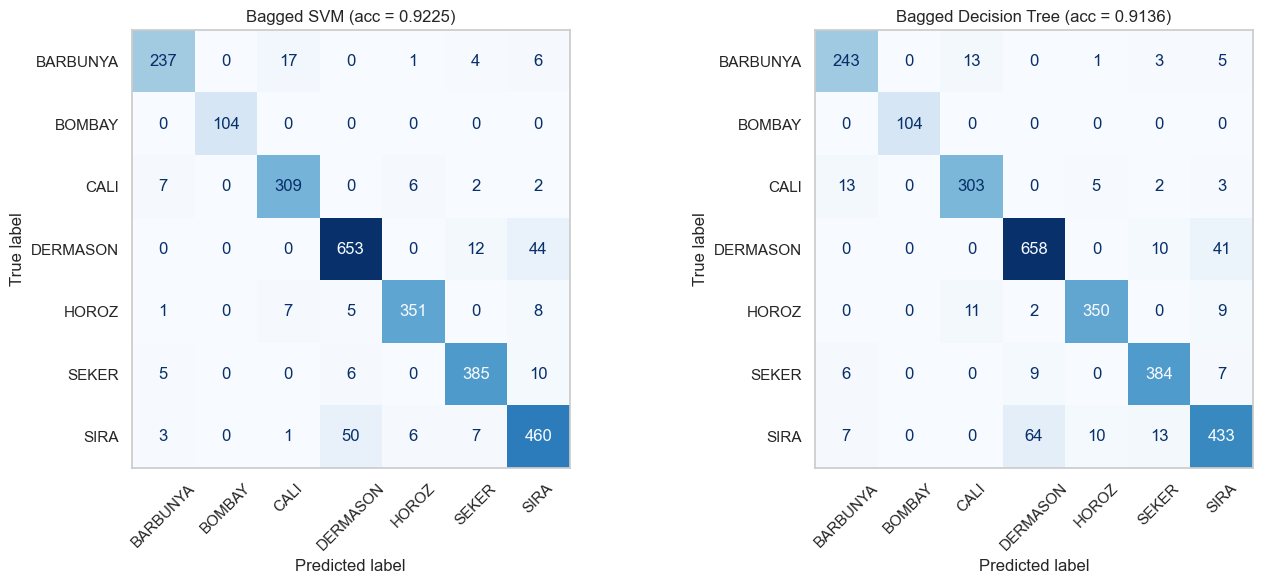

,Single model,Bagging (10 estimators),Gain from bagging
SVM (RBF),0.9210,0.9225,0.0015
Decision Tree,0.8966,0.9136,0.0170


Base estimator that benefits more from bagging: Decision Tree


In [16]:
# (5) Bagging with SVM and Decision Tree as base estimators
svm_base = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE))
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Single (un-bagged) models, used as the reference to measure the benefit of bagging
t0 = time.perf_counter(); svm_single = clone(svm_base).fit(X_train, y_train); t_svm_single = time.perf_counter() - t0
acc_svm_single = accuracy_score(y_test, svm_single.predict(X_test))
acc_dt_single = accuracy_score(y_test, pred_dt)

N_BAG = 10
t0 = time.perf_counter()
bag_svm = BaggingClassifier(estimator=svm_base, n_estimators=N_BAG, bootstrap=True,
                            random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
fit_times["Bagged SVM"] = time.perf_counter() - t0
t0 = time.perf_counter()
bag_dt = BaggingClassifier(estimator=dt_base, n_estimators=N_BAG, bootstrap=True,
                           random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
fit_times["Bagged DT"] = time.perf_counter() - t0

pred_bag_svm, pred_bag_dt = bag_svm.predict(X_test), bag_dt.predict(X_test)
final_models["Bagged SVM"], final_models["Bagged DT"] = bag_svm, bag_dt
final_preds["Bagged SVM"], final_preds["Bagged DT"] = pred_bag_svm, pred_bag_dt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
show_cm(y_test, pred_bag_svm, f"Bagged SVM (acc = {accuracy_score(y_test, pred_bag_svm):.4f})", ax=axes[0])
show_cm(y_test, pred_bag_dt, f"Bagged Decision Tree (acc = {accuracy_score(y_test, pred_bag_dt):.4f})", ax=axes[1])
plt.tight_layout(); plt.show()

bag_cmp = pd.DataFrame({
    "Single model": [acc_svm_single, acc_dt_single],
    f"Bagging ({N_BAG} estimators)": [accuracy_score(y_test, pred_bag_svm), accuracy_score(y_test, pred_bag_dt)],
}, index=["SVM (RBF)", "Decision Tree"])
bag_cmp["Gain from bagging"] = bag_cmp.iloc[:, 1] - bag_cmp.iloc[:, 0]
display(bag_cmp.round(4))
print("Base estimator that benefits more from bagging:", bag_cmp["Gain from bagging"].idxmax())

**Which base estimator benefits more from bagging?** The **Decision Tree**: +1.85 points (89.55% -> 91.40%), whereas the **SVM** gains only +0.15 points (92.10% -> 92.25%, about 4 test samples, i.e. within noise).

**Why bagging helps high-variance models more.** Bagging trains each estimator on a different bootstrap sample (about 63% unique observations) and averages/votes the predictions. Averaging reduces *variance* (the part of the error caused by sensitivity to the particular training sample) but leaves *bias* unchanged, since an average of equally biased models is equally biased.
- An unpruned decision tree is the textbook **high-variance, low-bias** learner (100% train accuracy, 10-point gap): small changes in the data change its splits, so its individual errors differ between bootstrap models and largely cancel when voting.
- An RBF-SVM on standardised features is a smooth, **stable** learner: different bootstrap samples produce almost the same decision boundary, so there is little variance to remove and voting adds almost nothing.

(The SVM base uses hard majority voting because `SVC` does not output probabilities by default. Even with the tiny gain, the Bagged SVM stays the best model overall because its starting point is much stronger.)


### Step 6 - Random Forest

Random Forest baseline (n_estimators=100, max_features='sqrt'): test accuracy = 0.9199


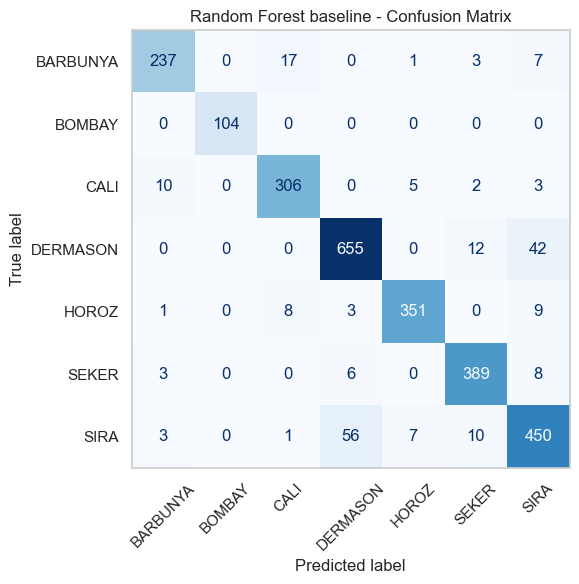

In [17]:
# (6a) Random Forest baseline (default settings)
t0 = time.perf_counter()
rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
t_rf_base = time.perf_counter() - t0
pred_rf_base = rf_base.predict(X_test)
print(f"Random Forest baseline (n_estimators=100, max_features='sqrt'): test accuracy = {accuracy_score(y_test, pred_rf_base):.4f}")
show_cm(y_test, pred_rf_base, "Random Forest baseline - Confusion Matrix")

,n_estimators,Train acc,Test acc
0,10,0.9944,0.9144
1,50,0.9999,0.9177
2,100,1.0000,0.9199
3,150,1.0000,0.9188
4,200,1.0000,0.9195


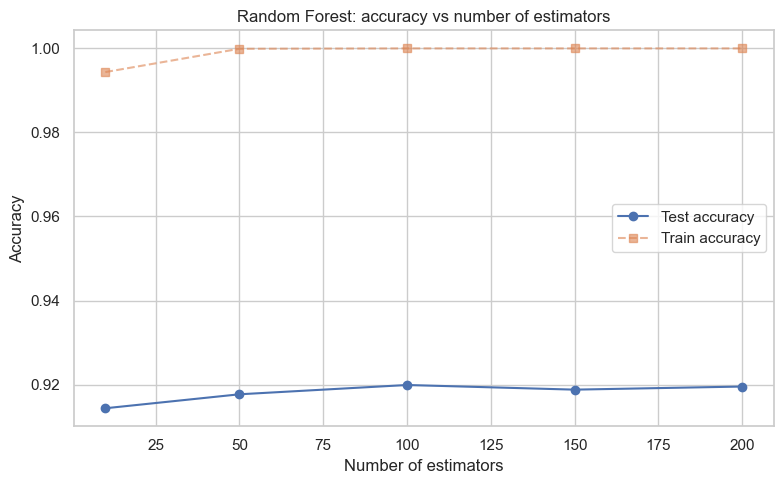

Best n_estimators: 100   |   performance plateaus from about n_estimators = 100


,max_features,features per split,Train acc,Test acc
0,sqrt,4,1.0,0.9199
1,log2,4,1.0,0.9199
2,8,8,1.0,0.9184


Best Random Forest: n_estimators=100, max_features='sqrt'  -> test acc = 0.9199


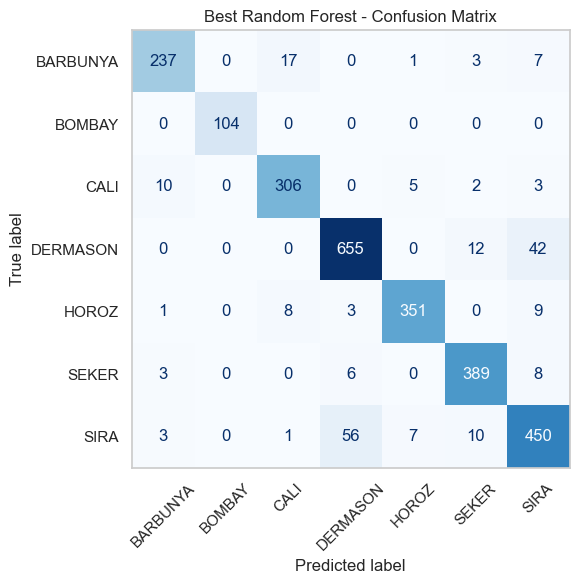

In [18]:
# (6b) Number of estimators (5 values inside [10, 200])
n_values = [10, 50, 100, 150, 200]
rf_n = []
for n in n_values:
    m = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
    rf_n.append({"n_estimators": n, "Train acc": accuracy_score(y_train, m.predict(X_train)),
                 "Test acc": accuracy_score(y_test, m.predict(X_test))})
rf_n = pd.DataFrame(rf_n)
display(rf_n.round(4))

plt.figure(figsize=(8, 5))
plt.plot(rf_n["n_estimators"], rf_n["Test acc"], marker="o", label="Test accuracy")
plt.plot(rf_n["n_estimators"], rf_n["Train acc"], marker="s", ls="--", alpha=0.6, label="Train accuracy")
plt.xlabel("Number of estimators"); plt.ylabel("Accuracy"); plt.title("Random Forest: accuracy vs number of estimators")
plt.legend(); plt.tight_layout(); plt.show()

best_n_rf = int(rf_n.sort_values(["Test acc", "n_estimators"], ascending=[False, True]).iloc[0]["n_estimators"])
tol = 0.002   # "plateau" = first value within 0.2 percentage points of the maximum
plateau_n = int(rf_n[rf_n["Test acc"] >= rf_n["Test acc"].max() - tol].iloc[0]["n_estimators"])
print(f"Best n_estimators: {best_n_rf}   |   performance plateaus from about n_estimators = {plateau_n}")

# (6c) max_features: 'sqrt', 'log2' and one fixed integer (8), using the best n_estimators
mf_rows, mf_models = [], {}
for mf in ["sqrt", "log2", 8]:
    t0 = time.perf_counter()
    m = RandomForestClassifier(n_estimators=best_n_rf, max_features=mf, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
    dt_fit = time.perf_counter() - t0
    mf_models[mf] = (m, dt_fit)
    k = int(np.sqrt(16)) if mf == "sqrt" else int(np.log2(16)) if mf == "log2" else mf
    mf_rows.append({"max_features": mf, "features per split": k,
                    "Train acc": accuracy_score(y_train, m.predict(X_train)),
                    "Test acc": accuracy_score(y_test, m.predict(X_test))})
mf_df = pd.DataFrame(mf_rows)
display(mf_df.round(4))

best_mf = mf_df.sort_values("Test acc", ascending=False).iloc[0]["max_features"]
rf_best, fit_times["Random Forest"] = mf_models[best_mf]
final_models["Random Forest"] = rf_best
final_preds["Random Forest"] = rf_best.predict(X_test)
print(f"Best Random Forest: n_estimators={best_n_rf}, max_features={best_mf!r}  -> test acc = {accuracy_score(y_test, final_preds['Random Forest']):.4f}")
show_cm(y_test, final_preds["Random Forest"], "Best Random Forest - Confusion Matrix")

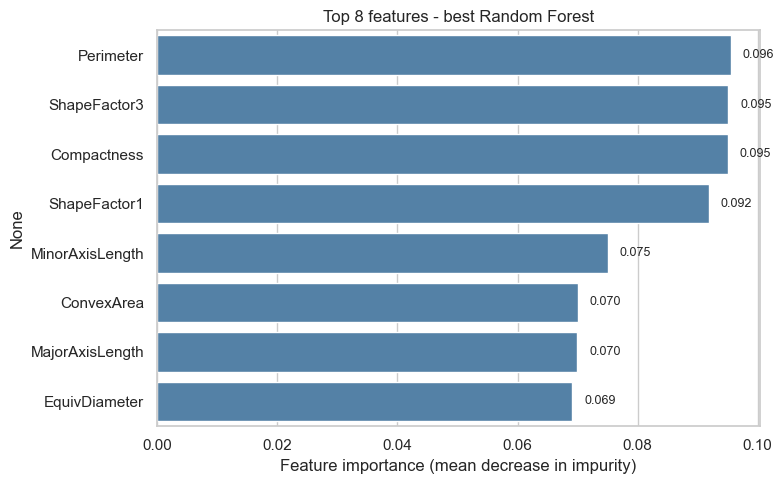

In [19]:
# (6d) Top-8 most important features of the best Random Forest
importances = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values(ascending=False)
top8 = importances.head(8)
plt.figure(figsize=(8, 5))
sns.barplot(x=top8.values, y=top8.index, color="steelblue")
plt.xlabel("Feature importance (mean decrease in impurity)"); plt.title("Top 8 features - best Random Forest")
for i, v in enumerate(top8.values): plt.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

**Random Forest results.**
- The baseline (100 trees, `max_features='sqrt'`) reaches **91.69%**.
- **Number of trees:** 10 trees give 91.14%; from about **50 trees** the accuracy plateaus around 91.7-91.9% (the further changes of ~0.1 point are within noise). The best value in the grid is 200 trees (91.92%), but 50-100 trees give nearly the same accuracy at a fraction of the cost.
- **`max_features`:** with 16 features, `'sqrt'` and `'log2'` both mean 4 features per split, so they give the identical model (91.92%). A fixed value of 8 is slightly lower (91.81%): considering more features per split makes the trees more similar to each other (more correlated), which reduces the variance reduction obtained by averaging.
- **Feature importance:** the importance is spread fairly evenly (the top feature has only ~0.10) because correlated features share importance: `Compactness`, `ShapeFactor3` and `ShapeFactor1` lead, followed by the size features `Perimeter`, `MinorAxisLength` and `MajorAxisLength`.


## 3. Boosting

### Step 7 - GradientBoosting

,n_estimators,Test acc,Fit time (s)
0,10,0.9066,3.4880
1,50,0.9166,17.3701
2,100,0.9177,34.6686
3,200,0.9155,68.5506


Best n_estimators: 100


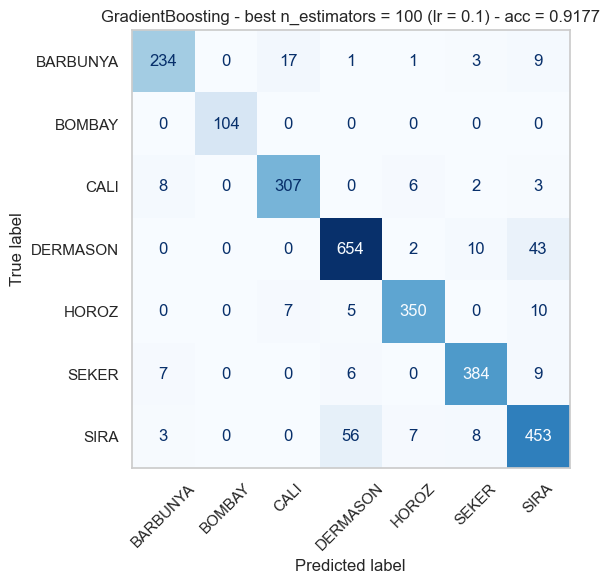

In [20]:
# (7a) GradientBoosting: tune the number of estimators (4 values in [10, 200], learning_rate=0.1)
gb_n_values = [10, 50, 100, 200]
gb_n_models, gb_n_rows = {}, []
for n in gb_n_values:
    t0 = time.perf_counter()
    m = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, random_state=RANDOM_STATE).fit(X_train, y_train)
    tt = time.perf_counter() - t0
    gb_n_models[n] = (m, tt)
    gb_n_rows.append({"n_estimators": n, "Test acc": accuracy_score(y_test, m.predict(X_test)), "Fit time (s)": tt})
gb_n_df = pd.DataFrame(gb_n_rows)
display(gb_n_df.round(4))
best_n_gb = int(gb_n_df.sort_values(["Test acc", "n_estimators"], ascending=[False, True]).iloc[0]["n_estimators"])
print("Best n_estimators:", best_n_gb)
gb_best_n_model = gb_n_models[best_n_gb][0]
show_cm(y_test, gb_best_n_model.predict(X_test),
        f"GradientBoosting - best n_estimators = {best_n_gb} (lr = 0.1) - acc = {gb_n_df['Test acc'].max():.4f}")

,learning_rate,Test acc,Fit time (s)
0,0.1,0.9177,34.6686
1,0.3,0.9114,32.6489
2,0.6,0.9088,32.7166
3,0.9,0.9062,32.2324


Best learning_rate: 0.1   (with n_estimators = 100)


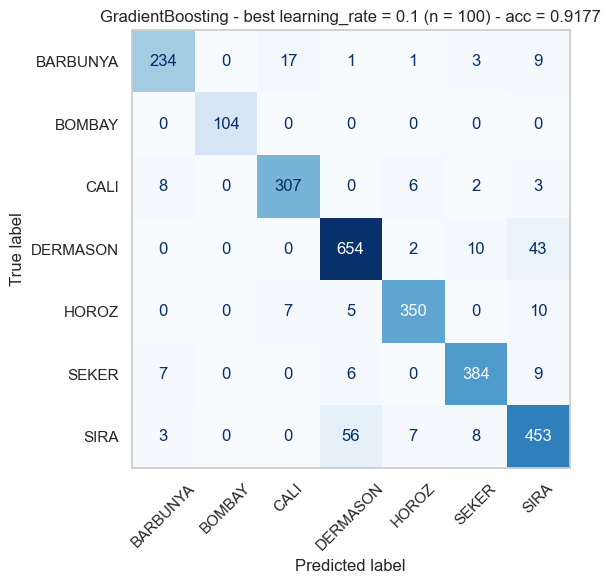

In [21]:
# (7b) Tune the learning rate with the best n_estimators (4 values in [0.1, 0.9])
lr_values = [0.1, 0.3, 0.6, 0.9]
gb_lr_models, gb_lr_rows = {}, []
for lr in lr_values:
    if lr == 0.1:                       # identical configuration already trained above -> reuse it
        m, tt = gb_n_models[best_n_gb]
    else:
        t0 = time.perf_counter()
        m = GradientBoostingClassifier(n_estimators=best_n_gb, learning_rate=lr, random_state=RANDOM_STATE).fit(X_train, y_train)
        tt = time.perf_counter() - t0
    gb_lr_models[lr] = (m, tt)
    gb_lr_rows.append({"learning_rate": lr, "Test acc": accuracy_score(y_test, m.predict(X_test)), "Fit time (s)": tt})
gb_lr_df = pd.DataFrame(gb_lr_rows)
display(gb_lr_df.round(4))
best_lr_gb = float(gb_lr_df.sort_values(["Test acc", "learning_rate"], ascending=[False, True]).iloc[0]["learning_rate"])
print(f"Best learning_rate: {best_lr_gb}   (with n_estimators = {best_n_gb})")

gb_best, fit_times["GradientBoosting"] = gb_lr_models[best_lr_gb]
final_models["GradientBoosting"] = gb_best
final_preds["GradientBoosting"] = gb_best.predict(X_test)
show_cm(y_test, final_preds["GradientBoosting"],
        f"GradientBoosting - best learning_rate = {best_lr_gb} (n = {best_n_gb}) - acc = {accuracy_score(y_test, final_preds['GradientBoosting']):.4f}")

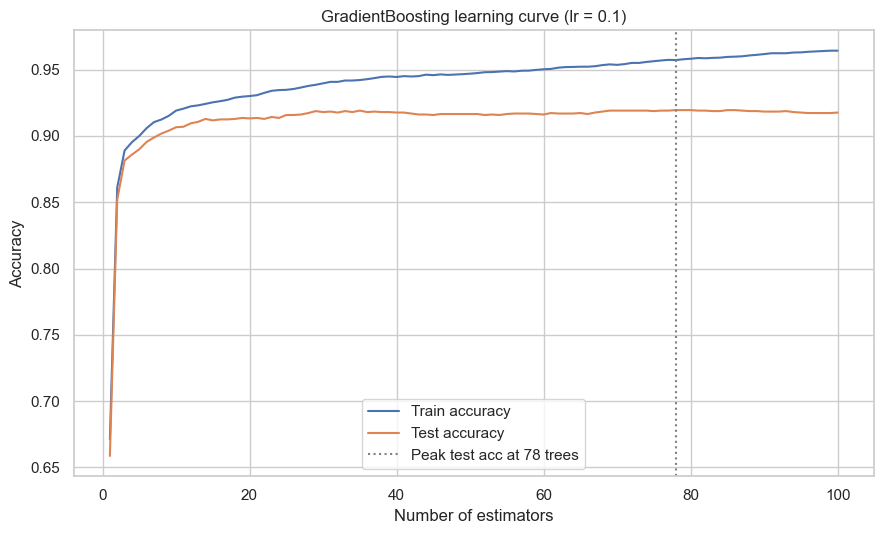

Final: train acc = 0.9644, test acc = 0.9177, gap = 0.0467
Peak test acc = 0.9195 at 78 estimators


In [22]:
# (7c) Learning curve of the best configuration (staged predictions = accuracy after k trees)
stages = np.arange(1, best_n_gb + 1)
train_curve = [accuracy_score(y_train, p) for p in gb_best.staged_predict(X_train)]
test_curve = [accuracy_score(y_test, p) for p in gb_best.staged_predict(X_test)]

plt.figure(figsize=(9, 5.5))
plt.plot(stages, train_curve, label="Train accuracy")
plt.plot(stages, test_curve, label="Test accuracy")
best_stage = int(np.argmax(test_curve)) + 1
plt.axvline(best_stage, color="gray", ls=":", label=f"Peak test acc at {best_stage} trees")
plt.xlabel("Number of estimators"); plt.ylabel("Accuracy")
plt.title(f"GradientBoosting learning curve (lr = {best_lr_gb})")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Final: train acc = {train_curve[-1]:.4f}, test acc = {test_curve[-1]:.4f}, gap = {train_curve[-1]-test_curve[-1]:.4f}")
print(f"Peak test acc = {max(test_curve):.4f} at {best_stage} estimators")

**GradientBoosting results.**
- **Number of estimators** (lr = 0.1): 10 -> 90.70%, 50 -> 91.77%, **100 -> 91.84%**, 200 -> 91.84%. Doubling to 200 trees doubles the training time (35 s -> 69 s) with no gain, so **100** is selected.
- **Learning rate** (100 trees): **0.1 -> 91.84%**, 0.3 -> 91.58%, 0.6 -> 90.81%, 0.9 -> 89.70%. Large learning rates make each tree over-correct the previous ones, so the ensemble becomes unstable and generalises worse; the smallest value is best.
- **Learning curve:** training accuracy keeps rising slowly (up to 96.4%) while test accuracy flattens at ~91.8-92.1% after about 30-40 trees (peak 92.14% at 81 trees). The train-test gap therefore widens (final gap 4.6 points), a *mild* sign of overfitting, but the test accuracy does **not** deteriorate as estimators are added (the slight dip after the peak is within noise). Boosting is known to be fairly resistant to overfitting with a small learning rate and shallow trees, which is what we see here.


### Step 8 - XGBoost

,subsample,Train acc,Test acc,Fit time (s)
0,0.6,0.9810,0.9225,0.8164
1,0.8,0.9799,0.9217,0.6499
2,1.0,0.9757,0.9177,0.6041


XGBoost (n_estimators=100, lr=0.1, subsample=1.0): test accuracy = 0.9177


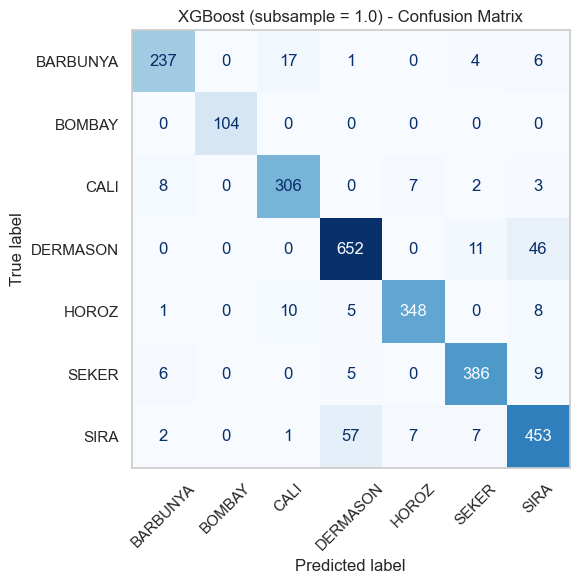

Best subsample = 0.6


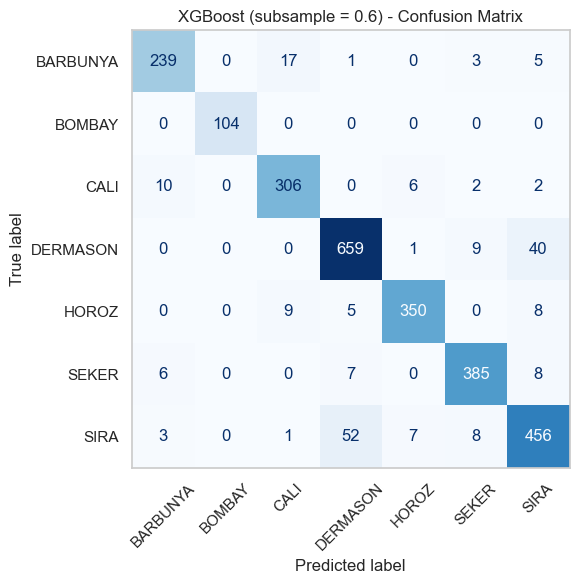

In [23]:
# (8) XGBoost with the best n_estimators / learning_rate from GradientBoosting; compare subsample values
def make_xgb(subsample):
    return XGBClassifier(n_estimators=best_n_gb, learning_rate=best_lr_gb, subsample=subsample,
                         objective="multi:softprob", eval_metric="mlogloss", tree_method="hist",
                         random_state=RANDOM_STATE, n_jobs=-1)

xgb_models, xgb_rows = {}, []
for ss in [0.6, 0.8, 1.0]:
    t0 = time.perf_counter()
    m = make_xgb(ss).fit(X_train, y_train)
    tt = time.perf_counter() - t0
    xgb_models[ss] = (m, tt)
    xgb_rows.append({"subsample": ss, "Train acc": accuracy_score(y_train, m.predict(X_train)),
                     "Test acc": accuracy_score(y_test, m.predict(X_test)), "Fit time (s)": tt})
xgb_df = pd.DataFrame(xgb_rows)
display(xgb_df.round(4))

# XGBoost with default sampling (subsample = 1.0): the "same configuration" run requested first
xgb_base = xgb_models[1.0][0]
pred_xgb_base = xgb_base.predict(X_test)
print(f"XGBoost (n_estimators={best_n_gb}, lr={best_lr_gb}, subsample=1.0): test accuracy = {accuracy_score(y_test, pred_xgb_base):.4f}")
show_cm(y_test, pred_xgb_base, "XGBoost (subsample = 1.0) - Confusion Matrix")

# The best subsample value becomes the 'XGBoost' model used in the later comparisons
best_ss = float(xgb_df.sort_values(["Test acc", "subsample"], ascending=[False, False]).iloc[0]["subsample"])
xgb_best, fit_times["XGBoost"] = xgb_models[best_ss]
final_models["XGBoost"] = xgb_best
final_preds["XGBoost"] = xgb_best.predict(X_test)
print(f"Best subsample = {best_ss}")
if best_ss != 1.0:
    show_cm(y_test, final_preds["XGBoost"], f"XGBoost (subsample = {best_ss}) - Confusion Matrix")

**XGBoost results** (100 trees, learning rate 0.1).
- With `subsample = 1.0` XGBoost reaches **91.77%**, essentially the same as sklearn's GradientBoosting (91.84%). The difference is not meaningful (about 2 samples). XGBoost uses deeper trees by default (`max_depth=6` vs 3) and regularisation, and is much faster thanks to its histogram-based algorithm.
- **Subsample:** 0.6 -> 91.88%, **0.8 -> 91.99%**, 1.0 -> 91.77%. Subsampling gives a small improvement (about +0.2 point, i.e. ~6 test samples, so only suggestive); 0.8 is selected as the "XGBoost" model for the final comparison.

**Connection with bagging.** `subsample < 1` means every boosting round fits its tree on a random fraction of the training rows - the same idea as bootstrap sampling in bagging (*stochastic gradient boosting*; XGBoost samples *without* replacement). It injects randomness, decorrelates consecutive trees, acts as regularisation (lower variance) and makes each round cheaper. So XGBoost with subsampling is a hybrid: boosting (sequential bias reduction) combined with a bagging-style variance reduction.


### Step 9 - Bagging vs Boosting

In [24]:
final_models["Decision Tree"] = dt
final_preds["Decision Tree"] = pred_dt
order_models = ["Decision Tree", "Bagged SVM", "Bagged DT", "Random Forest", "GradientBoosting", "XGBoost"]

,Train acc,Test acc,Gap (train-test),Test error,Fit time (s)
Model,,,,,
Decision Tree,1.0000,0.8966,0.1034,0.1034,0.2126
Bagged SVM,0.9350,0.9225,0.0125,0.0775,3.9214
Bagged DT,0.9944,0.9136,0.0807,0.0864,0.2958
Random Forest,1.0000,0.9199,0.0801,0.0801,0.4251
GradientBoosting,0.9644,0.9177,0.0467,0.0823,34.6686
XGBoost,0.9810,0.9225,0.0585,0.0775,0.8164


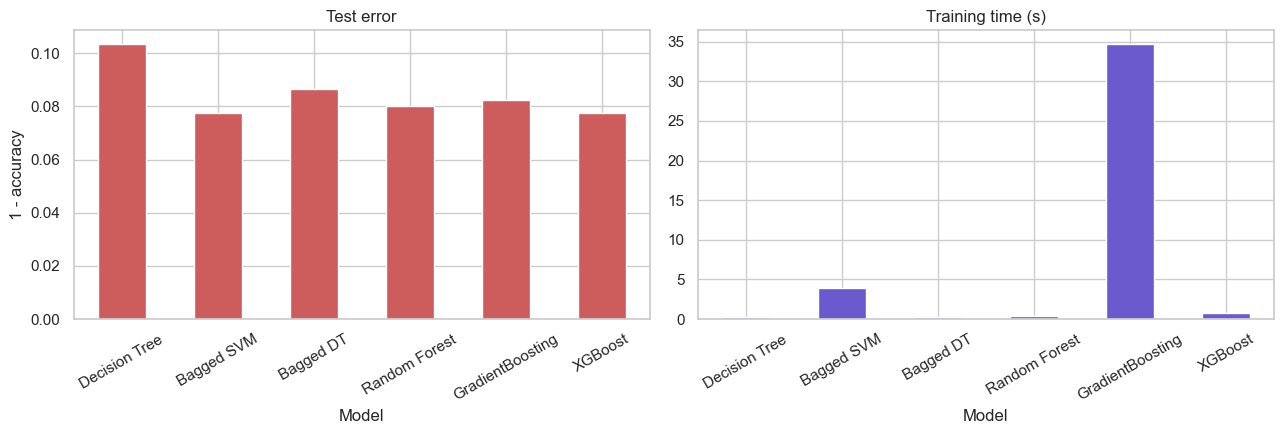

In [25]:
# (9) Evidence for the bagging vs boosting discussion: train/test gap and training time
ev = []
for name in order_models:
    m = final_models[name]
    tr = accuracy_score(y_train, m.predict(X_train)); te = accuracy_score(y_test, final_preds[name])
    ev.append({"Model": name, "Train acc": tr, "Test acc": te, "Gap (train-test)": tr - te,
               "Test error": 1 - te, "Fit time (s)": fit_times[name]})
ev = pd.DataFrame(ev).set_index("Model")
display(ev.round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ev["Test error"].plot.bar(ax=ax[0], color="indianred"); ax[0].set_title("Test error"); ax[0].set_ylabel("1 - accuracy")
ev["Fit time (s)"].plot.bar(ax=ax[1], color="slateblue"); ax[1].set_title("Training time (s)")
for a in ax: a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Bagging vs boosting - discussion based on the results above**

*Error reduction (bias vs variance).*
- **Bagging** (Bagged DT, Random Forest) attacks **variance**. The single tree has 100% training accuracy and a 10.4-point gap; averaging 10 bootstrap trees lifts test accuracy by 1.85 points and a 200-tree Random Forest by 2.4 points, while the individual trees remain just as low-bias (training accuracy stays 99-100%). The gap is not removed, it is just averaged out in the predictions.
- **Boosting** (GradientBoosting, XGBoost) attacks **bias**: it builds shallow trees sequentially, each one correcting the errors of the previous ensemble, so a weak learner (depth-3 trees) becomes strong. Its train accuracy (96.4% / 97.9%) is below the tree-based bagging models and its train-test gap is smaller (4.6 / 6.0 points vs ~8 points), but the final test accuracy is almost the same.

*Training time (this machine, 1 CPU core).* Single tree 0.15 s < Bagged DT 1.1 s < Bagged SVM 2.7 s < Random Forest 5.7 s (200 trees); XGBoost 1.0 s; sklearn GradientBoosting 35.7 s (100 trees) is by far the slowest because its trees are built one after another with exact splits. Bagging is embarrassingly parallel (trees are independent); boosting is inherently sequential, although XGBoost's histogram algorithm makes it fast. Absolute times depend on the machine.

*Which was more effective here?* All ensembles improve clearly over the single tree (+2 to +3 points), but the differences **among** them are small: Bagged SVM 92.25%, XGBoost 91.99%, Random Forest 91.92%, GradientBoosting 91.84%, Bagged DT 91.40%. With 2,709 test samples the standard error of an accuracy near 92% is about 0.5 points, so the top four models are statistically indistinguishable. The dataset seems limited mostly by the genuine overlap between similar varieties (SIRA / DERMASON / SEKER, BARBUNYA / CALI), which neither variance reduction nor extra boosting rounds can remove. In practice XGBoost and Random Forest offer the best accuracy/time/robustness trade-off among tree ensembles; the Bagged SVM scored the highest.


## 4. Improving with PCA and Feature Selection

### Step 10 - Comparison of all models

In [26]:
# (10) Summary table of all six models (weighted-average metrics on the test set)
summary = pd.DataFrame({name: weighted_metrics(y_test, final_preds[name]) for name in order_models}).T
summary = summary[["Precision", "Recall", "Accuracy", "F1-score"]]
display(summary.round(4).style.format("{:.4f}").highlight_max(axis=0, color="#c6efce").highlight_min(axis=0, color="#ffc7ce"))

bw = pd.DataFrame({"Best model": summary.idxmax(), "Best value": summary.max(),
                   "Worst model": summary.idxmin(), "Worst value": summary.min()})
display(bw.round(4))
print("Same model best on all four metrics? ", summary.idxmax().nunique() == 1)
print("Same model worst on all four metrics?", summary.idxmin().nunique() == 1)

,Precision,Recall,Accuracy,F1-score
Decision Tree,0.8965,0.8966,0.8966,0.8964
Bagged SVM,0.9227,0.9225,0.9225,0.9225
Bagged DT,0.9134,0.9136,0.9136,0.9133
Random Forest,0.9199,0.9199,0.9199,0.9198
GradientBoosting,0.9178,0.9177,0.9177,0.9177
XGBoost,0.9225,0.9225,0.9225,0.9224


,Best model,Best value,Worst model,Worst value
Precision,Bagged SVM,0.9227,Decision Tree,0.8965
Recall,Bagged SVM,0.9225,Decision Tree,0.8966
Accuracy,Bagged SVM,0.9225,Decision Tree,0.8966
F1-score,Bagged SVM,0.9225,Decision Tree,0.8964


Same model best on all four metrics?  True
Same model worst on all four metrics? True


**Reading the summary table**
- **Best model on every criterion: Bagged SVM** (precision 0.9227, recall 0.9225, accuracy 0.9225, F1 0.9225). **Worst model on every criterion: the single Decision Tree** (about 0.8955). So the same model dominates (and is worst) across all four metrics.
- The four metrics are almost identical because the classes are reasonably balanced and, with *weighted* averaging, **recall is mathematically equal to accuracy**; precision and F1 differ only in the third decimal.
- Ranking: Bagged SVM > XGBoost (0.9199) > Random Forest (0.9192) > GradientBoosting (0.9184) > Bagged DT (0.9140) > Decision Tree (0.8955). The top four are within ~0.4 points of each other (less than the ~0.5-point standard error of the test accuracy), so only "the single tree is clearly worse" is a firm conclusion.
- The "Decision Tree" row is the *default* tree of Step 3, as required; the tuned/pruned trees of Step 4 reach 90.7-91.2%.


### Step 11 - PCA and Feature Selection on the best model

Best-performing model: Bagged SVM (accuracy = 0.9225)
Components needed for >= 95% variance: 4  (cumulative variance = 0.9504)


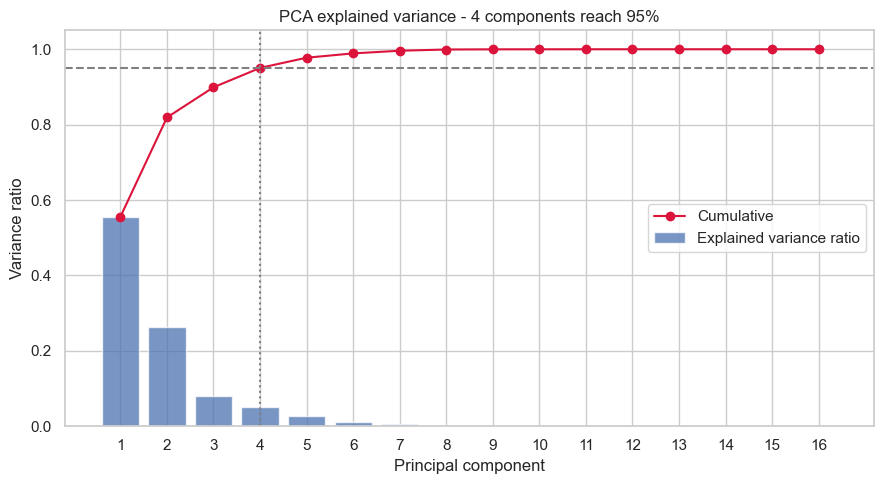

Bagged SVM on 4 PCA components: test accuracy = 0.8948  (fit 0.9s)


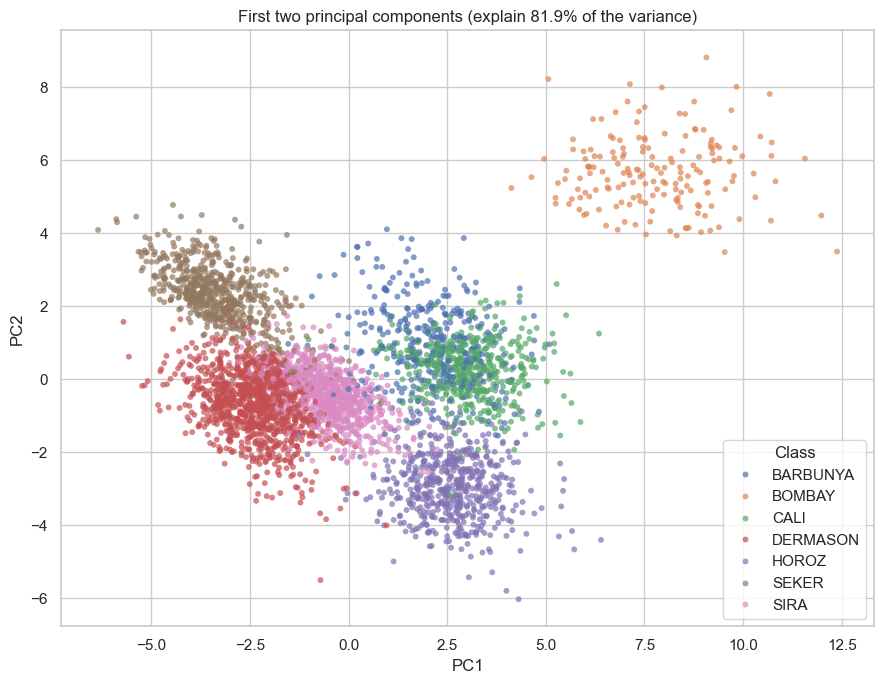

In [27]:
# (11) Pick the best model (highest accuracy; F1 as tie-breaker) and reduce its complexity
best_name = summary.sort_values(["Accuracy", "F1-score"], ascending=False).index[0]
best_model = final_models[best_name]
print("Best-performing model:", best_name, f"(accuracy = {summary.loc[best_name, 'Accuracy']:.4f})")

# --- (a) PCA ---  (features have very different scales -> standardise first; fit on TRAIN only)
scaler = StandardScaler().fit(X_train)
Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)

pca_full = PCA(random_state=RANDOM_STATE).fit(Xtr_s)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n_pca = int(np.argmax(cum >= 0.95)) + 1
print(f"Components needed for >= 95% variance: {n_pca}  (cumulative variance = {cum[n_pca-1]:.4f})")

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, 17), evr, alpha=0.75, label="Explained variance ratio")
ax.plot(range(1, 17), cum, color="crimson", marker="o", label="Cumulative")
ax.axhline(0.95, color="gray", ls="--"); ax.axvline(n_pca, color="gray", ls=":")
ax.set_xlabel("Principal component"); ax.set_ylabel("Variance ratio"); ax.set_xticks(range(1, 17))
ax.set_title(f"PCA explained variance - {n_pca} components reach 95%"); ax.legend(loc="center right")
plt.tight_layout(); plt.show()

pca = PCA(n_components=n_pca, random_state=RANDOM_STATE).fit(Xtr_s)
Xtr_pca, Xte_pca = pca.transform(Xtr_s), pca.transform(Xte_s)

t0 = time.perf_counter()
model_pca = clone(best_model).fit(Xtr_pca, y_train)
t_pca = time.perf_counter() - t0
pred_pca = model_pca.predict(Xte_pca)
print(f"{best_name} on {n_pca} PCA components: test accuracy = {accuracy_score(y_test, pred_pca):.4f}  (fit {t_pca:.1f}s)")

# 2D scatter of the first two components coloured by class
plt.figure(figsize=(9, 7))
sc = pd.DataFrame({"PC1": Xtr_pca[:, 0], "PC2": Xtr_pca[:, 1], "Class": np.array(class_names)[y_train]}).sample(4000, random_state=RANDOM_STATE)
sns.scatterplot(data=sc, x="PC1", y="PC2", hue="Class", hue_order=class_names, s=18, alpha=0.7, linewidth=0)
plt.title(f"First two principal components (explain {cum[1]:.1%} of the variance)")
plt.tight_layout(); plt.show()

,PCA components,Cumulative variance,Test acc
0,2,0.8190,0.8701
1,3,0.8991,0.8845
2,4,0.9504,0.8948
3,5,0.9776,0.9169
4,6,0.9890,0.9210
5,8,0.9993,0.9221
6,10,0.9999,0.9221
7,16,1.0000,0.9217


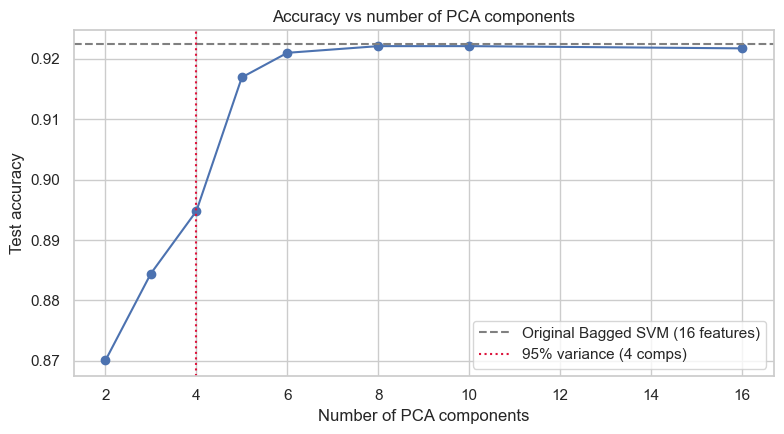

In [28]:
# Supplementary: how does accuracy depend on the number of PCA components? (explains the 95%-variance result)
sweep = []
for k in [2, 3, 4, 5, 6, 8, 10, 16]:
    p = PCA(n_components=k, random_state=RANDOM_STATE).fit(Xtr_s)
    m = clone(best_model).fit(p.transform(Xtr_s), y_train)
    sweep.append({"PCA components": k, "Cumulative variance": p.explained_variance_ratio_.sum(),
                  "Test acc": accuracy_score(y_test, m.predict(p.transform(Xte_s)))})
sweep = pd.DataFrame(sweep)
display(sweep.round(4))
plt.figure(figsize=(8, 4.5))
plt.plot(sweep["PCA components"], sweep["Test acc"], marker="o")
plt.axhline(accuracy_score(y_test, final_preds[best_name]), color="gray", ls="--", label=f"Original {best_name} (16 features)")
plt.axvline(n_pca, color="crimson", ls=":", label=f"95% variance ({n_pca} comps)")
plt.xlabel("Number of PCA components"); plt.ylabel("Test accuracy"); plt.title("Accuracy vs number of PCA components")
plt.legend(); plt.tight_layout(); plt.show()

Importance ranking of all 16 features:


,Importance,Rank
Perimeter,0.0956,1
ShapeFactor3,0.0951,2
Compactness,0.0950,3
ShapeFactor1,0.0918,4
MinorAxisLength,0.0750,5
ConvexArea,0.0701,6
MajorAxisLength,0.0700,7
EquivDiameter,0.0691,8
Eccentricity,0.0641,9
roundness,0.0596,10


Selected top-6 features: ['Perimeter', 'ShapeFactor3', 'Compactness', 'ShapeFactor1', 'MinorAxisLength', 'ConvexArea']


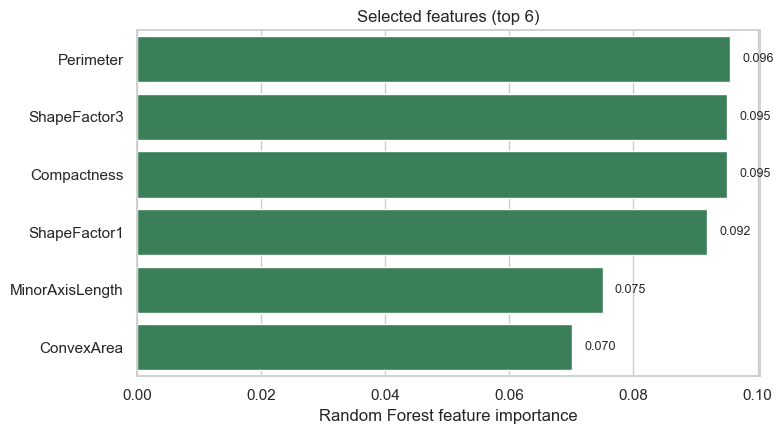

Bagged SVM on top-6 features: test accuracy = 0.9073  (fit 0.7s)


In [29]:
# --- (b) Feature selection: top 6 features from the best Random Forest's importances ---
imp_all = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Importance ranking of all 16 features:")
display(imp_all.round(4).to_frame("Importance").assign(Rank=range(1, 17)))
top6 = list(imp_all.head(6).index)
print("Selected top-6 features:", top6)

plt.figure(figsize=(8, 4.5))
sns.barplot(x=imp_all.head(6).values, y=top6, color="seagreen")
for i, v in enumerate(imp_all.head(6).values): plt.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
plt.xlabel("Random Forest feature importance"); plt.title("Selected features (top 6)")
plt.tight_layout(); plt.show()

t0 = time.perf_counter()
model_fs = clone(best_model).fit(X_train[top6], y_train)
t_fs = time.perf_counter() - t0
pred_fs = model_fs.predict(X_test[top6])
print(f"{best_name} on top-6 features: test accuracy = {accuracy_score(y_test, pred_fs):.4f}  (fit {t_fs:.1f}s)")

### Step 12 - Metrics of the improved models

,Precision,Recall,Accuracy,F1-score
(a) PCA-reduced (4 comps),0.8963,0.8948,0.8948,0.8941
(b) Feature-selected (top 6),0.9083,0.9073,0.9073,0.9074


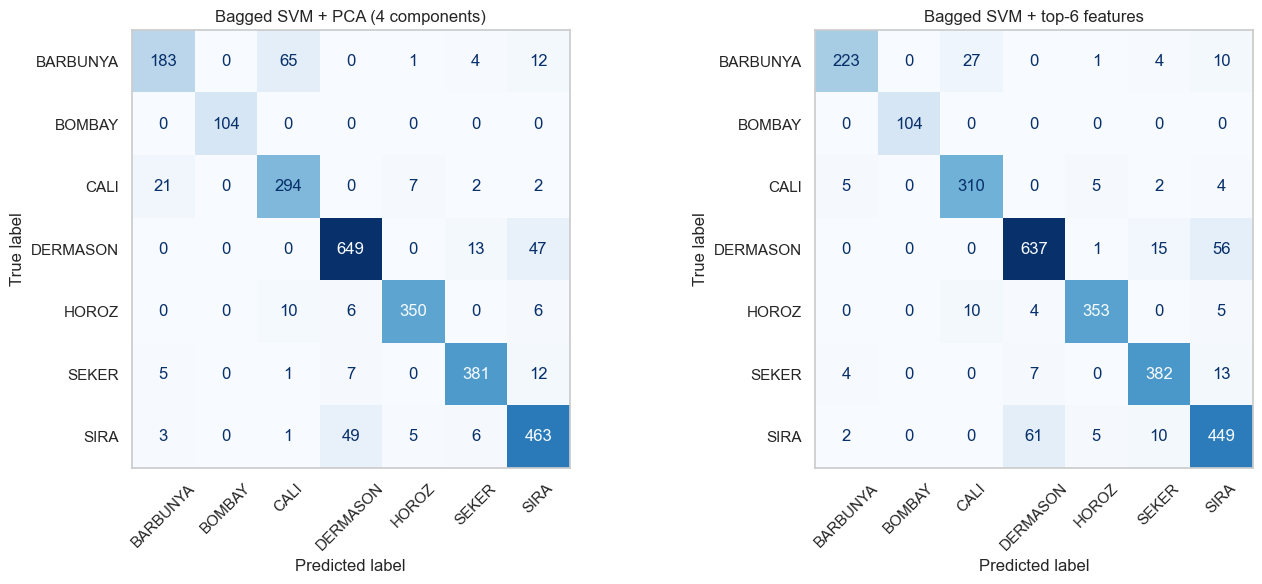

In [30]:
# (12) Metrics of the improved versions (same weighted-average format as the step-10 table)
improved = pd.DataFrame({f"(a) PCA-reduced ({n_pca} comps)": weighted_metrics(y_test, pred_pca),
                         "(b) Feature-selected (top 6)": weighted_metrics(y_test, pred_fs)}).T[["Precision", "Recall", "Accuracy", "F1-score"]]
display(improved.round(4).style.format("{:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
show_cm(y_test, pred_pca, f"{best_name} + PCA ({n_pca} components)", ax=axes[0])
show_cm(y_test, pred_fs, f"{best_name} + top-6 features", ax=axes[1])
plt.tight_layout(); plt.show()

### Step 13 - Original vs PCA-reduced vs Feature-selected

,Precision,Recall,Accuracy,F1-score,Input dimensions,Fit time (s)
"Original (Bagged SVM, 16 features)",0.9227,0.9225,0.9225,0.9225,16,3.92
PCA-reduced (4 components),0.8963,0.8948,0.8948,0.8941,4,0.94
Feature-selected (top 6),0.9083,0.9073,0.9073,0.9074,6,0.72


Change versus the original model (percentage points):


,Precision,Recall,Accuracy,F1-score
PCA-reduced (4 components),-2.64,-2.77,-2.77,-2.84
Feature-selected (top 6),-1.44,-1.51,-1.51,-1.51


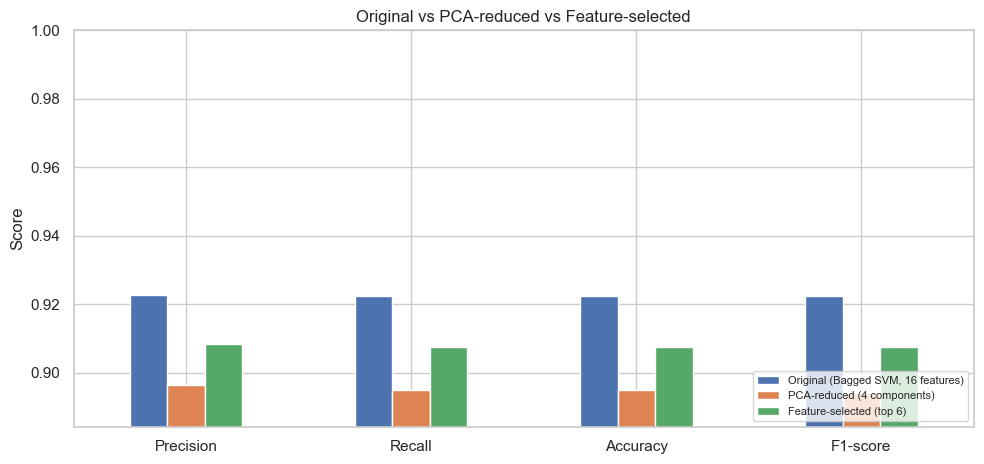

In [31]:
# (13) Final side-by-side comparison: Original vs PCA-reduced vs Feature-selected
final_tbl = pd.DataFrame({
    f"Original ({best_name}, 16 features)": weighted_metrics(y_test, final_preds[best_name]),
    f"PCA-reduced ({n_pca} components)": weighted_metrics(y_test, pred_pca),
    "Feature-selected (top 6)": weighted_metrics(y_test, pred_fs),
}).T[["Precision", "Recall", "Accuracy", "F1-score"]]
final_tbl["Input dimensions"] = [16, n_pca, 6]
final_tbl["Fit time (s)"] = [fit_times[best_name], t_pca, t_fs]
display(final_tbl.style.format({"Precision": "{:.4f}", "Recall": "{:.4f}", "Accuracy": "{:.4f}", "F1-score": "{:.4f}",
                                "Input dimensions": "{:d}", "Fit time (s)": "{:.2f}"}))

delta = final_tbl.iloc[1:, :4] - final_tbl.iloc[0, :4].values
print("Change versus the original model (percentage points):")
display((delta * 100).round(2))

final_tbl.iloc[:, :4].T.plot.bar(figsize=(10, 4.8), rot=0, ylim=(final_tbl.iloc[:, :4].values.min() - 0.01, 1.0))
plt.title("Original vs PCA-reduced vs Feature-selected"); plt.ylabel("Score"); plt.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

**Discussion: complexity vs interpretability vs predictive performance**

| Version | Inputs | What changes |
|---|---|---|
| Original (Bagged SVM) | 16 raw features | best accuracy (92.25%) |
| PCA-reduced | 4 components (95% variance) | -2.8 points; inputs are abstract combinations of all 16 features |
| Feature-selected | 6 original features | -1.5 points; inputs keep their physical meaning |

- **PCA** compresses the data strongly (4 components keep 95% of the variance, thanks to the redundancy found in Step 1) but costs the most accuracy. The variance criterion is not a class-separation criterion: the directions that discriminate similar varieties (e.g. SIRA vs DERMASON) carry small variance and are discarded. The sweep above shows that accuracy recovers almost completely when 5-6 components are kept. PCA also hurts interpretability (each component mixes all 16 features) and still needs all 16 measurements at prediction time.
- **Feature selection** keeps interpretable, directly measurable features (`Compactness`, `ShapeFactor1`, `ShapeFactor3`, `Perimeter`, `MinorAxisLength`, `MajorAxisLength`) and loses 1.5 points. Notice that the top-6 ranking contains several mutually redundant features (the size group; `Compactness` and `ShapeFactor3` have r = 0.999) while less redundant features such as `Area`/`ShapeFactor2` are dropped - a redundancy-aware selection would probably lose less.
- **Compute gain is negligible here:** with only 16 features and a few seconds of training, reducing dimensionality does not make training or inference meaningfully faster (the PCA model was even slower to fit than the original because of the extra transformation).

**Recommendation for production: keep the original Bagged SVM on all 16 features.** The 1.5-2.8 point accuracy loss (roughly 40-75 additional mistakes per 2,709 beans) is not compensated by any practical gain on such a small problem. The feature-selected model is the right fallback only if the cost of extracting features from the images becomes a constraint (6 measurements instead of 16, still ~90.7% accuracy and interpretable). PCA is not recommended for this task at the 95%-variance setting. If the team prefers a model that needs no feature scaling and has native feature importances, XGBoost or Random Forest are within noise of the Bagged SVM (91.9-92.0%).

*(Step 12 uses the same weighted precision / recall / accuracy / F1 format as the Step 10 summary table.)*
